# Побудова моделі


<h2>Мета</h2>

Ознайомитись з різновидами регресійних моделей. Після завершення цієї лабораторної роботи ви зможете:

* Будувати регресійні моделі кількох видів
* Оцінювати якість моделі візуально
* Оцінювати якість моделі за допомогою числових мір, без використання тестової вибірки
* Виконувати прогнозування відгуку, використовуючи побудовану модель



<div class="alert alert-danger alertdanger" style="margin-top: 20px">

# <h1 id="task">Завдання, що оцінюються </h1>

</div>

1. Скачати дані з фінального файлу першої роботи з виправленими помилками та заповненими пропусками. Записати дані у dataframe. В попередній роботі ви визначили ознаки, що можуть бути предикторами для 'CO2 emission'. Побудуйте моделі лінійної регресії для кожного з цих предикторів.
2. Побудуйте модель множинної лінійної регресії для всіх доречних предикторів разом.
3. Побудуйте кілька поліноміальних моделей другого порядку.
4. Побудуйте візуалізації для оцінки всіх моделей.
5. Порахуйте значення R^2 та MSE для оцінки якості кожної моделі. Оберіть найкращу модель.


<a name="task1"></a>
<div class="alert alert-success alertsuccess" style="margin-top: 20px">

## <h2 id="task1">Завдання  #1: </h2>



Зчитую дані з файлу у датафрейм


In [1]:
# Напишіть ваш код нижче та натисніть Shift+Enter для виконання
import pandas as pd
df = pd.read_csv('clean_data.csv', index_col=0)
df.head()

,Country Name,Region,GDP per capita,Population,CO2 emission,Area,Population density
0,Afghanistan,South Asia,561.778746,34656032.0,9809.225,652860,53.083405
1,Albania,Europe & Central Asia,4124.982390,2876101.0,5716.853,28750,100.038296
2,Algeria,Middle East & North Africa,3916.881571,40606052.0,145400.217,2381740,17.048902
3,American Samoa,East Asia & Pacific,11834.745230,55599.0,6501.591,200,277.995000
4,Andorra,Europe & Central Asia,36988.622030,77281.0,462.042,470,164.427660


<p>З попередньої роботи знаємо, що хорошими показниками для 'CO2 emission' можуть бути:</p>
<ul>
    <li>Population</li>
    <li>Area</li>
</ul>
Розробимо моделі, використовуючи ці ознаки як змінні-предиктори.

<p>Створюю об’єкт лінійної регресії та навчаю першу модель</p>


In [2]:
# Напишіть ваш код нижче та натисніть Shift+Enter для виконання
from sklearn.linear_model import LinearRegression
x1 = df[['Population']]
y1 = df[['CO2 emission']]
lm1= LinearRegression()
lm1.fit(x1, y1)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


Знаходжу коефіцієнти моделі


In [3]:
# Напишіть ваш код нижче та натисніть Shift+Enter для виконання
print(lm1.intercept_)
print(lm1.coef_)

[-8404.37142621]
[[0.00484808]]


Отримали кінцеву лінійну модель зі структурою:
$$
Yhat1 = a + b  X
$$

Підставляючи фактичні значення, маємо:

In [4]:
# Напишіть рівняння моделі, виконувати не потрібно

# Yhat1 = -8404.37 + 0.0048 * Population

Створюю об’єкт лінійної регресії та навчаю другу модель


In [5]:
# Напишіть ваш код нижче та натисніть Shift+Enter для виконання
x2 = df[['Area']]
y2 = df[['CO2 emission']]
lm2= LinearRegression()
lm2.fit(x2, y2)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


Знаходжу коефіцієнти моделі


In [6]:
# Напишіть ваш код нижче та натисніть Shift+Enter для виконання
print(lm2.intercept_)
print(lm2.coef_)


[-4181.76061729]
[[0.26093456]]


Отримали кінцеву лінійну модель зі структурою:
$$
Yhat2 = a + b  X
$$

Підставляючи фактичні значення, маємо:


In [7]:
# Напишіть рівняння моделі, виконувати не потрібно
# Yhat2 = -4181.76 + 0.261 * Area

<a name="task2"></a>
<div class="alert alert-success alertsuccess" style="margin-top: 20px">

## <h2 id="task2">Завдання  #2: </h2>

<p>Побудуйте модель множинної лінійної регресії для всіх доречних предикторів разом.</p>
</div>

Створюю об’єкт лінійної регресії та навчаю множинну лінійну модель із структурою
$$
Yhat3 = a + b_1 X_1 + b_2 X_2
$$

In [8]:
# Напишіть ваш код нижче та натисніть Shift+Enter для виконання
x3 = df[['Population', 'Area']]
y3 = df[['CO2 emission']]
lm3= LinearRegression()
lm3.fit(x3, y3)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


Знаходжу коефіцієнти моделі


In [9]:
# Напишіть ваш код нижче та натисніть Shift+Enter для виконання
print(lm3.intercept_)
print(lm3.coef_)


[-59329.0476349]
[[0.00407831 0.12480348]]


Підставляючи фактичні значення, маємо:

In [10]:
# Напишіть рівняння моделі, виконувати не потрібно

# Yhat3 = -59329.0476 + 0.0041 * Population + 0.1248 * Area

<a name="task3"></a>
<div class="alert alert-success alertsuccess" style="margin-top: 20px">

## <h2 id="task3">Завдання  #3: </h2>

<p>Побудуйте кілька поліноміальних моделей другого порядку.</p>
</div>

Створюю об’єкт поліноміальної регресії та навчаю поліноміальну модель із структурою
$$
Yhat4 = a + b_1 X_1 + b_2 X_1^2  
$$

Знаходжу коефіцієнти моделі


In [11]:
# Напишіть ваш код нижче та натисніть Shift+Enter для виконання
import numpy as np
x4 = df['Population']
y4 = df['CO2 emission']
f4 = np.polyfit(x4, y4, 2)
p4 = np.poly1d(f4)
print(p4)

            2
-3.846e-13 x + 0.00533 x - 1.751e+04


Створюю об’єкт поліноміальної регресії та навчаю поліноміальну модель із структурою
$$
Yhat5 = a + b_1 X_2 + b_2 X_2^2
$$

Знаходжу коефіцієнти моделі


In [12]:
# Напишіть ваш код нижче та натисніть Shift+Enter для виконання
x5 = df['Area']
y5 = df['CO2 emission']
f5 = np.polyfit(x5, y5, 2)
p5 = np.poly1d(f5)
print(p5)

           2
-1.52e-08 x + 0.4416 x - 5.963e+04


Створюю об’єкт поліноміальної регресії та навчаю поліноміальну модель із структурою
$$
Yhat6 = a + b_1 X_1 + b_2 X_2 + b_3 X_1 X_2 + b_4 X_1^2 + b_5 X_2^2
$$

Знаходжу коефіцієнти моделі


In [13]:
# Напишіть ваш код нижче та натисніть Shift+Enter для виконання
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

Input6 = [('scale',StandardScaler()), ('polynomial', PolynomialFeatures(include_bias=False)), ('model',LinearRegression())]
pipe6 = Pipeline(Input6)

x6 = df[['Population', 'Area']]
y6 = df['CO2 emission']
pipe6.fit(x6, y6)

print("Coefficients: ", pipe6.named_steps['model'].coef_)
print("Intercept: ",pipe6.named_steps['model'].intercept_)


Coefficients:  [372027.92569179 100774.52692872 -57060.27663041 249173.33869438
 -14520.16819742]
Intercept:  115818.22092601999


<a name="task4"></a>
<div class="alert alert-success alertsuccess" style="margin-top: 20px">

## <h2 id="task4">Завдання  #4: </h2>

<p>Побудуйте візуалізації для оцінки всіх моделей.</p>
</div>

Для простої лінійної регресії чудовим способом візуалізації відповідності моделі є використання графіків регресії. Цей графік покаже комбінацію розсіяних точок даних (діаграма розсіювання, scatterplot) та підігнану лінію лінійної регресії, що проходить через дані.

Таким способом візуалізую перші моделі.


(0.0, 11222906.913675169)

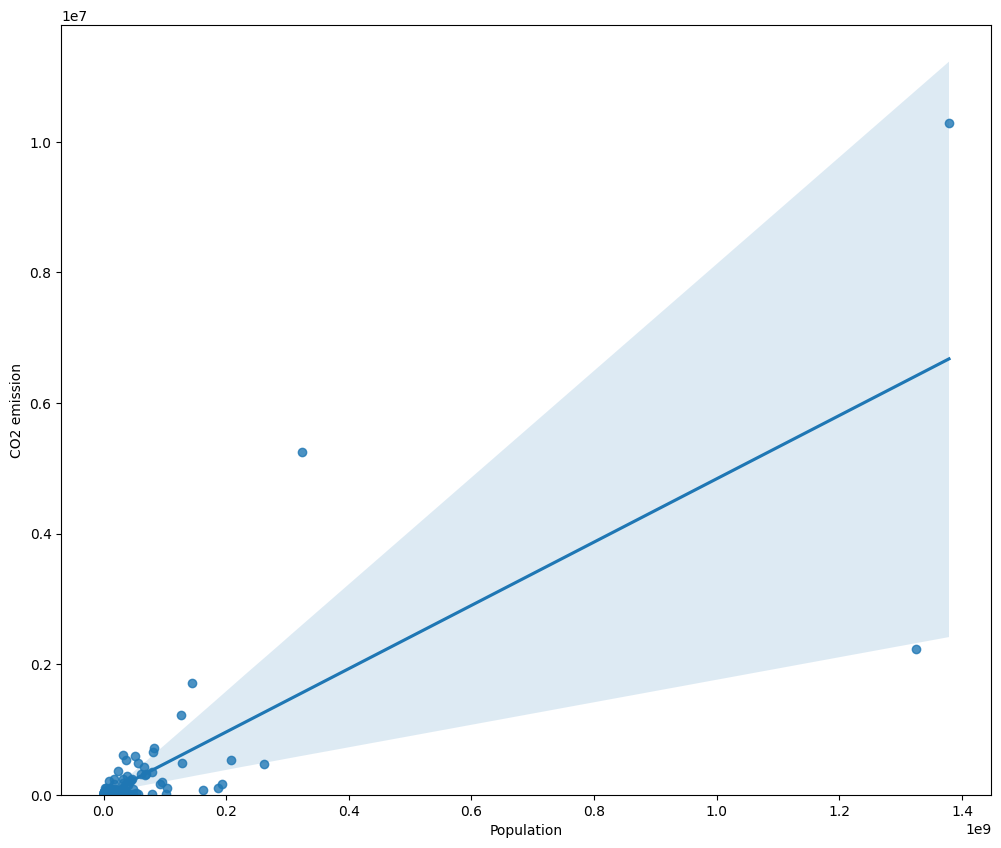

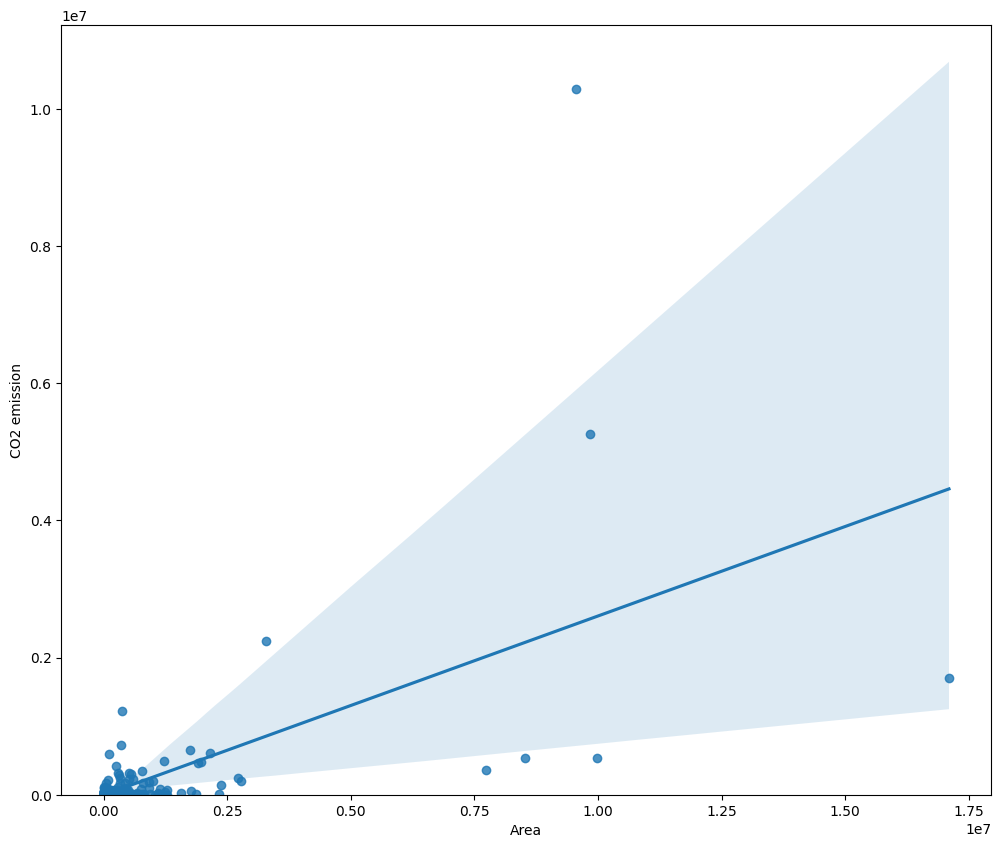

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

width = 12
height = 10
plt.figure(figsize=(width, height))
sns.regplot(x=x1, y=y1, data=df)
plt.ylim(0,)

plt.figure(figsize=(width, height))
sns.regplot(x=x2, y=y2, data=df)
plt.ylim(0,)

Для візуалізації дисперсії даних використаю діаграми залишків - по ній зможу прийняти рішення про необхідність ускладнення моделі.


<Axes: xlabel='Area', ylabel='CO2 emission'>

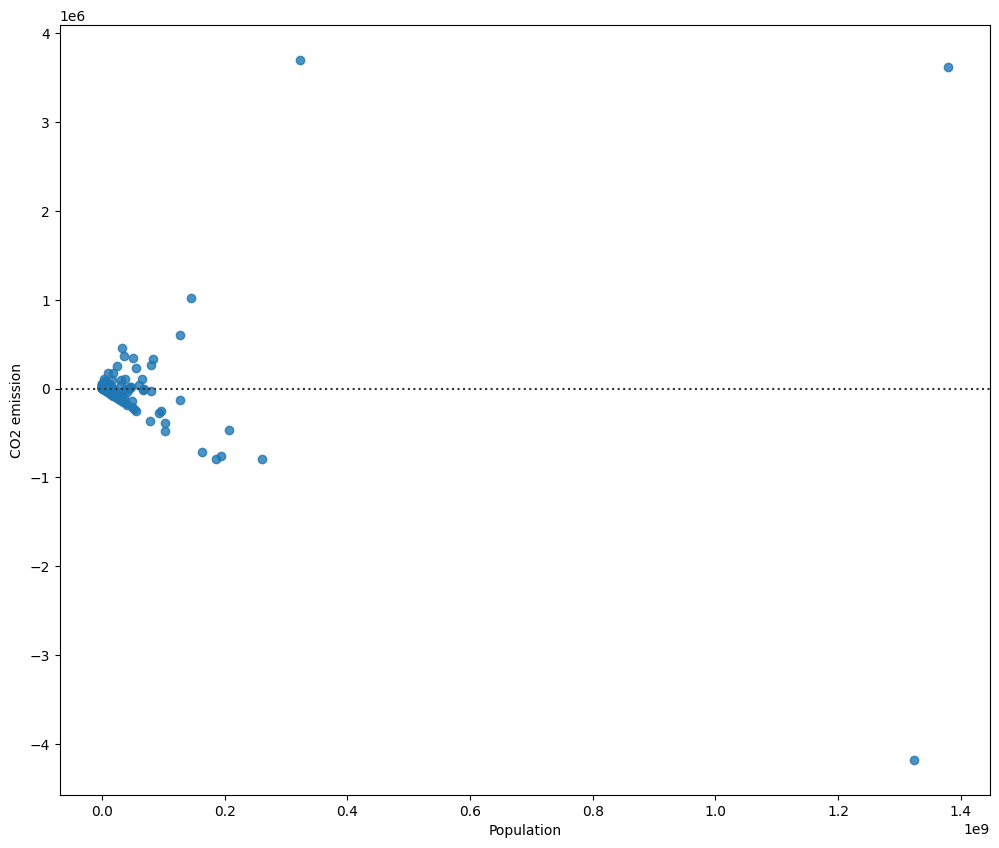

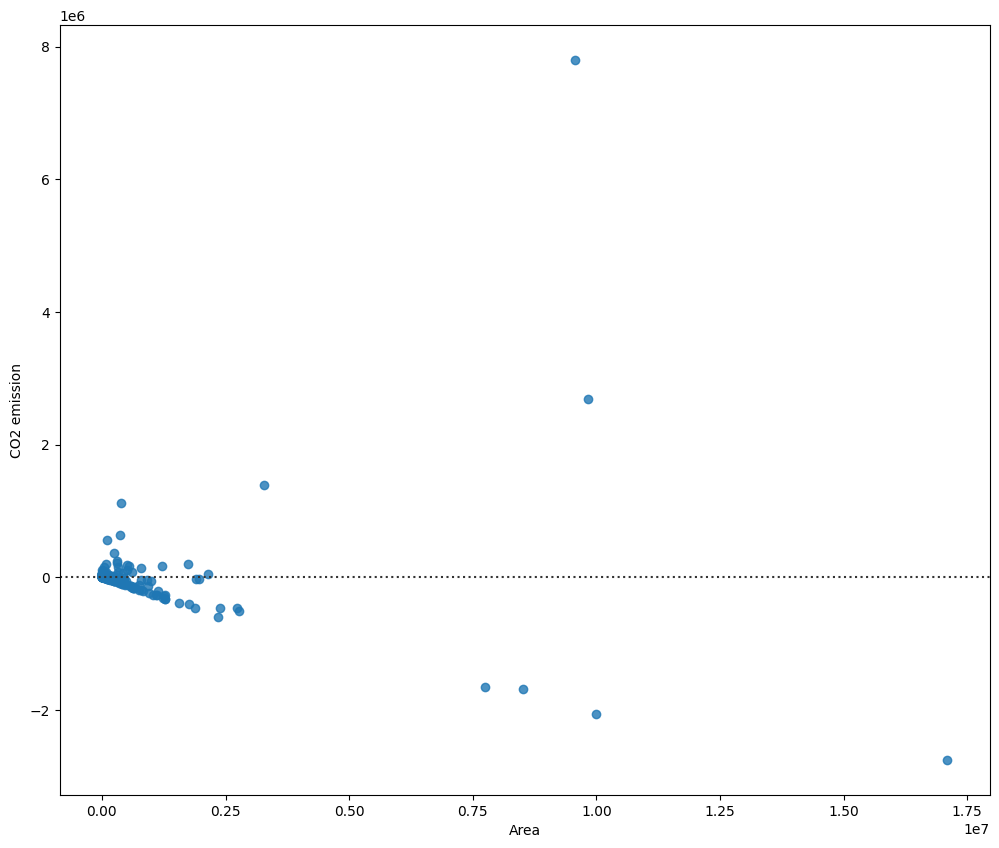

In [15]:
# Напишіть ваш код нижче та натисніть Shift+Enter для виконання
plt.figure(figsize=(width, height))
sns.residplot(x=x1, y=y1, data=df)

plt.figure(figsize=(width, height))
sns.residplot(x=x2, y=y2, data=df)

Первинний аналіз за допомогою простої лінійної регресії виявив суттєві недоліки моделі. На графіках залишків чітко видно, що похибка прогнозу для невеликих країн є мінімальною, проте зі зростанням населення та площі розкид помилок критично збільшується. Крім того, наявність вираженої структури (вигину) у залишках свідчить про те, що лінійна залежність від одного фактора не здатна адекватно описати викиди для країн-гігантів.

Для візуалізації моделі множинної лінійної регресії використаю діаграму розподілу.


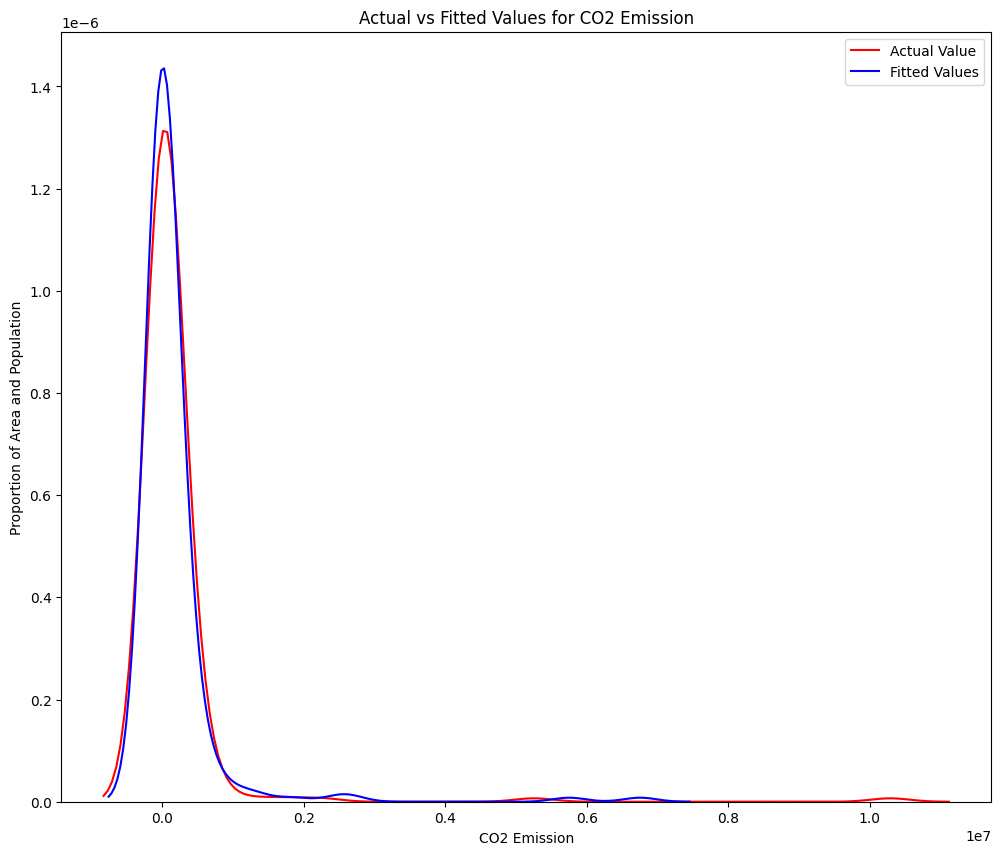

In [16]:
# Напишіть ваш код нижче та натисніть Shift+Enter для виконання
Y_hat3 = lm3.predict(x3)
plt.figure(figsize=(width, height))

sns.kdeplot(y3.squeeze(), color="r", label="Actual Value")
sns.kdeplot(Y_hat3.squeeze(), color="b", label="Fitted Values")

plt.title("Actual vs Fitted Values for CO2 Emission")
plt.xlabel("CO2 Emission")
plt.ylabel("Proportion of Area and Population")
plt.legend()

Для візуалізації поліноміальних моделей з одним предиктором використаю функцію <code>poly1d</code>. Зручно розміщувати всі моделі на одному графіку для обрання найкращої.


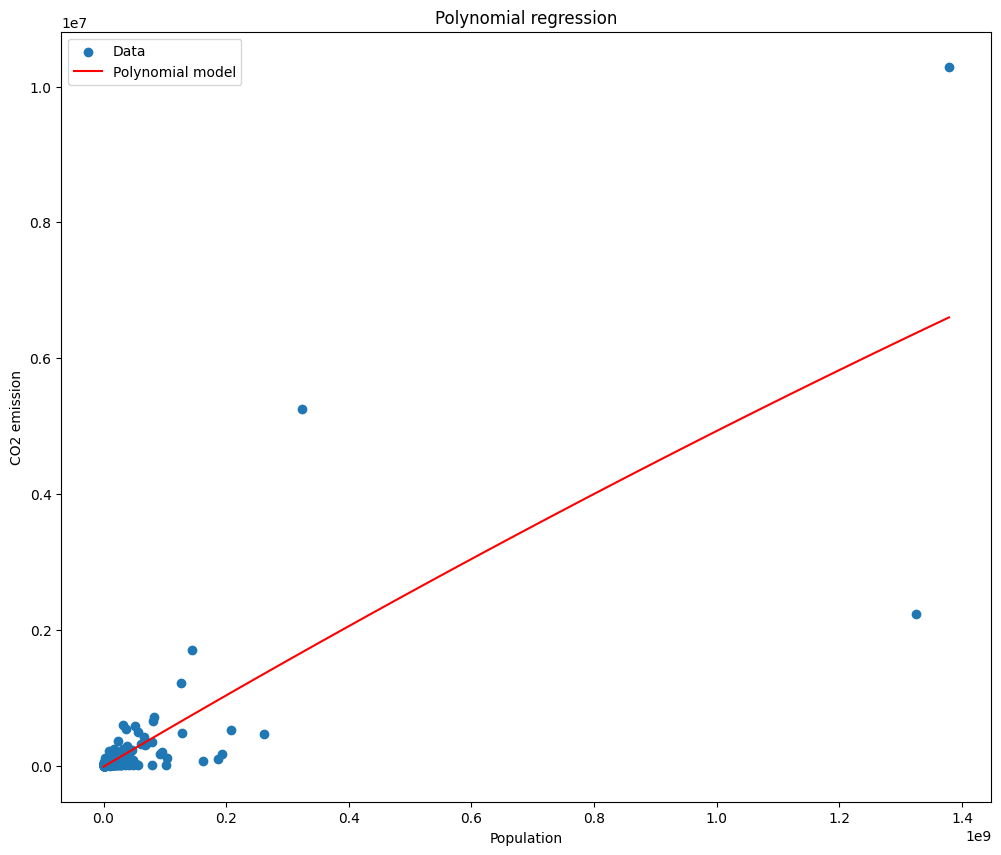

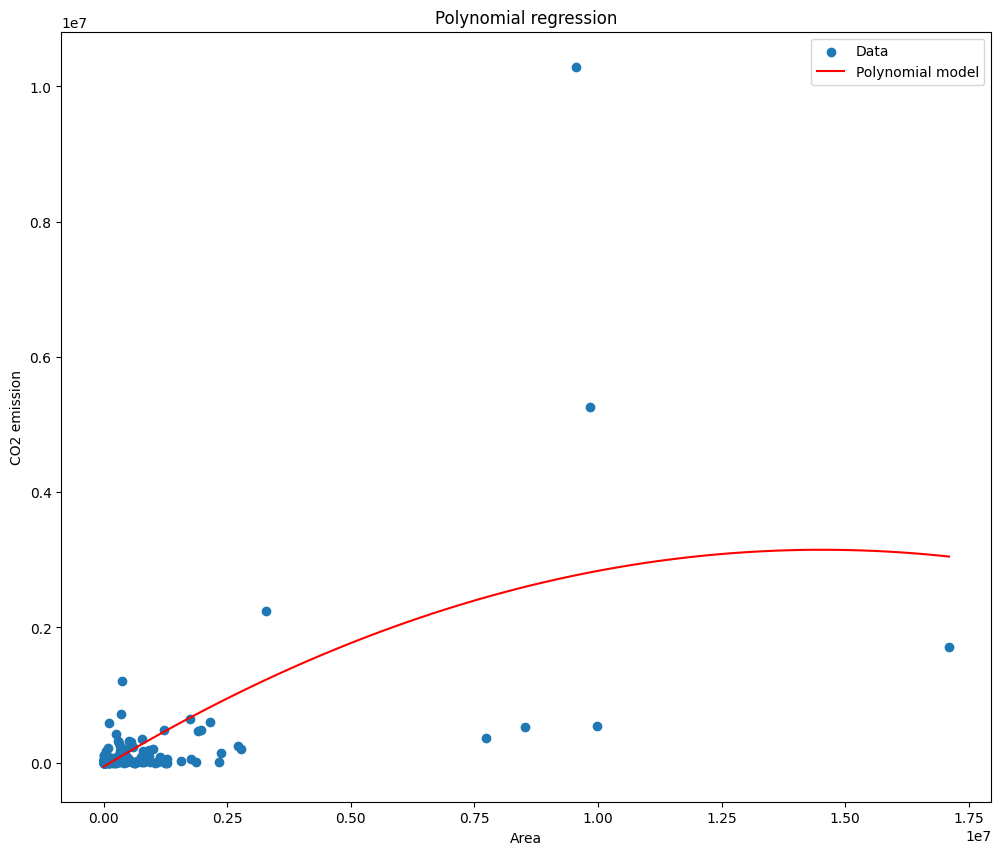

In [17]:
# Напишіть ваш код нижче та натисніть Shift+Enter для виконання
x_values = np.linspace(min(x4), max(x4), 100)
y_values = p4(x_values)
plt.figure(figsize=(width, height))
plt.scatter(x4, y4, label='Data')
plt.plot(x_values, y_values, color='red', label='Polynomial model')
plt.xlabel('Population')
plt.ylabel('CO2 emission')
plt.title('Polynomial regression')
plt.legend()

x_values = np.linspace(min(x5), max(x5), 100)
y_values = p5(x_values)
plt.figure(figsize=(width, height))
plt.scatter(x5, y5, label='Data')
plt.plot(x_values, y_values, color='red', label='Polynomial model')
plt.xlabel('Area')
plt.ylabel('CO2 emission')
plt.title('Polynomial regression')
plt.legend()

Для візуалізації поліноміальних моделей з кількома предикторами використаю діаграму розподілу або діаграму залишків


Text(0.5, 1.0, 'Residuals Plot')

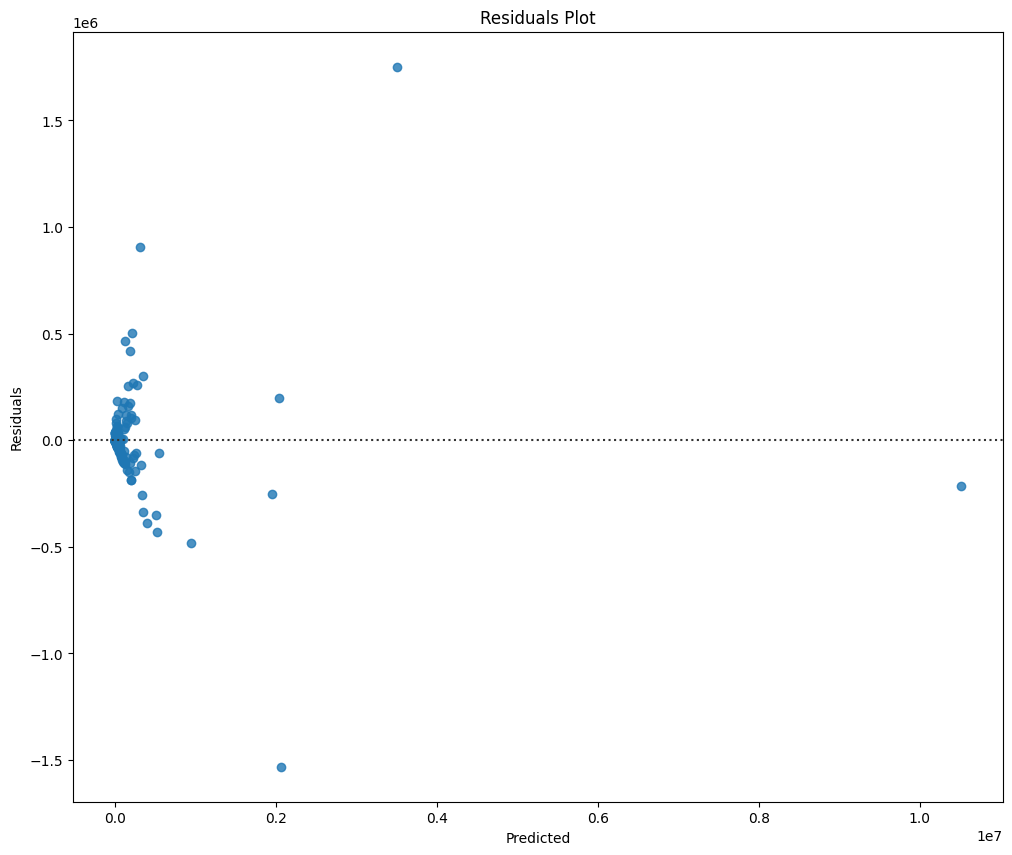

In [18]:
# Напишіть ваш код нижче та натисніть Shift+Enter для виконання
y_pred = pipe6.predict(x6)
residuals_df = pd.DataFrame({'Residuals': y6 - y_pred, 'Predicted': y_pred})
plt.figure(figsize=(width, height))
sns.residplot(x=residuals_df['Predicted'], y=residuals_df['Residuals'])
plt.title('Residuals Plot')

<a name="task5"></a>
<div class="alert alert-success alertsuccess" style="margin-top: 20px">

## <h2 id="task5">Завдання  #5: </h2>

<p>Порахуйте значення R^2 та MSE для оцінки якості кожної моделі. Оберіть найкращу модель.</p>
</div>

Значення R^2 отримую безпосередньо з моделі <code>.score(X, Y)</code>, а для розрахунку MSE спочатку формую прогнозовані значення <code>.predict(X)</code> і порівнюю їх з фактичними


Модель 1:
$$
Yhat1 = a + b  X
$$


In [19]:
# Напишіть ваш код нижче та натисніть Shift+Enter для виконання
from sklearn.metrics import r2_score, mean_squared_error
r2 = lm1.score(x1, y1)
print("R-squared for Population model: ", r2)
Yhat = lm1.predict(x1)
mse = mean_squared_error(y1, Yhat)
print("Mean Squared Error for Population model: ", mse)

R-squared for Population model:  0.6465810146980645
Mean Squared Error for Population model:  231214423278.44647


Модель 2:
$$
Yhat2 = a + b  X
$$

In [20]:
# Напишіть ваш код нижче та натисніть Shift+Enter для виконання
r2 = lm2.score(x2, y2)
print("R-squared for Population model: ", r2)
Yhat2 = lm2.predict(x2)
mse = mean_squared_error(y2, Yhat2)
print("Mean Squared Error for Population model: ", mse)

R-squared for Population model:  0.3461014134665431
Mean Squared Error for Population model:  427794744639.3072


Модель 3:
$$
Yhat3 = a + b_1 X_1 + b_2 X_2
$$

In [21]:
# Напишіть ваш код нижче та натисніть Shift+Enter для виконання
r3 = lm3.score(x3, y3)
print("R-squared for Population and Area model: ", r3)
Yhat3 = lm3.predict(x3)
mse = mean_squared_error(y3, Yhat3)
print("Mean Squared Error for Population and Area model: ", mse)

R-squared for Population and Area model:  0.7094563960895298
Mean Squared Error for Population and Area model:  190079974786.8917


Модель 4:
$$
Yhat4 = a + b_1 X_1 + b_2 X_1^2  
$$

In [22]:
r2 = r2_score(y4, p4(x4))
print("R-squared for Population and Area model: ", r2)
mse = mean_squared_error(y4, p4(x4))
print("Mean Squared Error for Population and Area model: ", mse)


R-squared for Population and Area model:  0.6470968295711803
Mean Squared Error for Population and Area model:  230876965916.60153


Модель 5:
$$
Yhat5 = a + b_1 X_2 + b_2 X_2^2
$$

In [23]:
# Напишіть ваш код нижче та натисніть Shift+Enter для виконання
r2 = r2_score(y5, p5(x5))
print("R-squared for Population and Area model: ", r2)
mse = mean_squared_error(y5, p5(x5))
print("Mean Squared Error for Population and Area model: ", mse)


R-squared for Population and Area model:  0.3743860417036333
Mean Squared Error for Population and Area model:  409290322756.32056


Модель 6:
$$
Yhat6 = a + b_1 X_1 + b_2 X_2 + b_3 X_1 X_2 + b_4 X_1^2 + b_5 X_2^2
$$

In [24]:
# Напишіть ваш код нижче та натисніть Shift+Enter для виконання
r2 = pipe6.score(x6, y6)
print("R-squared: ", r2)
Yhat6 = pipe6.predict(x6)
mse = mean_squared_error(y6, Yhat6)
print("Mean Squared Error: ", mse)

R-squared:  0.9380434208190209
Mean Squared Error:  40533348007.31493


<h4>Висновок</h4>

<p>Порівнюючи всі моделі, роблю висновок, що <b>модель 6 є найкращою моделлю</b> для прогнозування 'CO2 emission' на основі нашого набору даних, оскільки в результаті було отримано найвищий R^2 score та можна сказати, що 93.8% варіацій викидів CO2 пояснюються нею</p>


<a name="task6"></a>
<div class="alert alert-success alertsuccess" style="margin-top: 20px">

## <h2 id="task6"> Додаткове завдання: </h2>

<p>Побудуйте та оцініть кілька поліноміальних моделей різних порядків.</p>
</div>

1. Побудуйте кілька поліноміальних моделей різних порядків.
2. Побудуйте візуалізації для оцінки всіх моделей, починаючи з лінійної (зручно розміщувати всі моделі на одному графіку для обрання найкращої).
3. Порахуйте значення R^2 та MSE для оцінки якості кожної моделі (теж доцільно побудувати графік залежності R^2 або MSE від порядку поліному моделі).
4. Оберіть найкращу модель, висновок обгрунтуйте.


Degree 1: R^2 = 0.6466, MSE = 2.31e+11
Degree 2: R^2 = 0.6471, MSE = 2.31e+11
Degree 3: R^2 = 0.6024, MSE = 2.60e+11
Degree 4: R^2 = 0.6335, MSE = 2.40e+11
Degree 5: R^2 = 0.7267, MSE = 1.79e+11


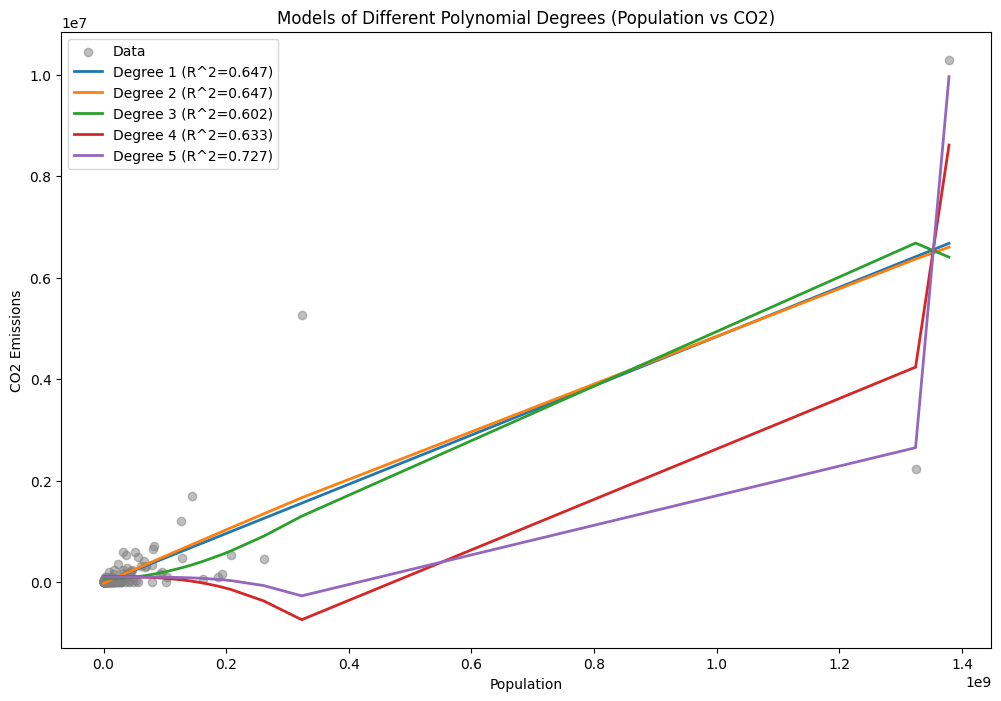

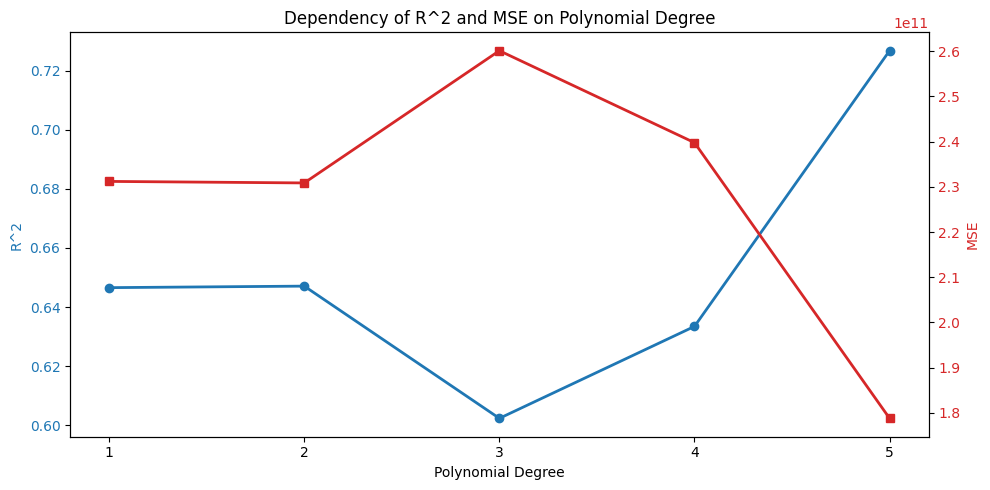

In [ ]:
degrees = range(1, 6)
r2_scores = []
mse_scores = []

df_sorted = df.sort_values(by='Population')
X_pop_sorted = df_sorted[['Population']]
Y_sorted = df_sorted['CO2 emission']

plt.figure(figsize=(12, 8))
plt.scatter(df_sorted['Population'], df_sorted['CO2 emission'], color='gray', alpha=0.5, label='Data')

for d in degrees:
    pr = PolynomialFeatures(degree=d, include_bias=False)
    X_poly = pr.fit_transform(X_pop_sorted)

    lm = LinearRegression()
    lm.fit(X_poly, Y_sorted)

    Y_pred = lm.predict(X_poly)

    r2 = r2_score(Y_sorted, Y_pred)
    mse = mean_squared_error(Y_sorted, Y_pred)
    r2_scores.append(r2)
    mse_scores.append(mse)

    plt.plot(df_sorted['Population'], Y_pred, label=f'Degree {d} (R^2={r2:.3f})', linewidth=2)

plt.title('Models of Different Polynomial Degrees (Population vs CO2)')
plt.xlabel('Population')
plt.ylabel('CO2 Emissions')
plt.legend()

fig, ax1 = plt.subplots(figsize=(10, 5))

color = 'tab:blue'
ax1.set_xlabel('Polynomial Degree')
ax1.set_ylabel('R^2', color=color)
ax1.plot(degrees, r2_scores, marker='o', color=color, linewidth=2)
ax1.tick_params(axis='y', labelcolor=color)
ax1.set_xticks(degrees)

ax2 = ax1.twinx()  
color = 'tab:red'
ax2.set_ylabel('MSE', color=color)  
ax2.plot(degrees, mse_scores, marker='s', color=color, linewidth=2)
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Dependency of R^2 and MSE on Polynomial Degree')
fig.tight_layout()  

for i, d in enumerate(degrees):
    print(f"Degree {d}: R^2 = {r2_scores[i]:.4f}, MSE = {mse_scores[i]:.2e}")

Найкращим вибором є лінійна модель (Порядок 1), оскільки високі порядки призводять до перенавчання та появи абсурдних прогнозів (від’ємних викидів), попри формально вищий R2.

<h2>Виконав студент групи ІП-44<br>  Комін Іван</h2>